In [1]:
from pathlib import Path
# import json
# import configparser
# import pprint
import time

# # pip install slicerio
# import slicerio.server

# # packages for 3d
# #   # for OCT 3D stuff and using in jupyter
# #   - trame-jupyter-extension
# #   - trame
# #   - trame-vtk
# #   - trame-vuetify
# #   - ipywidgets
import numpy as np
# import pandas as pd
import matplotlib.pyplot as plt
import cv2

import pyvista as pv
from PIL import Image
# import SimpleITK as sitk

# from zipfile import ZipFile
# import xml.etree.ElementTree as ET

import naatos_oct_tools.thorlabs_oct_file_reading

In [2]:
# Magics to autoreload submodules when they are modified
%load_ext autoreload
%autoreload 2

In [3]:
#%% Load OCT study information
#folder_octexport_root = Path(r'\\file.corp.ghlabs.org\Shared\Projects\NAATOS\V1\NAATOS_OCT_WORK\OCTExport')
folder_octexport_root = Path(r'D:\SGProjects\NAATOS\OCTlocal')
# this is also folder name

# strip 14
#study_name = 'GHL_pyapp_20250326T1416'
study_name = 'GHL_pyapp_20250327T1450'

octstudy = naatos_oct_tools.thorlabs_oct_file_reading.OCT_Study_Folder(study_name,folder_octexport_root);

STUDY: GHL_pyapp_20250327T1450
{   'study_has_an_ini_file': True,
    'study_has_json_info_file': True,
    'study_has_yat_log': False,
    'study_num_jpg_files': 0,
    'study_num_oct_files': 20,
    'study_num_vtk_files': 0}


In [4]:
octstudy.num_oct_files

20

In [5]:
octstudy

<OCT_Study_Folder Object>
GHL_pyapp_20250327T1450 in folder D:/SGProjects/NAATOS/OCTlocal
{   'study_has_an_ini_file': True,
    'study_has_json_info_file': True,
    'study_has_yat_log': False,
    'study_num_jpg_files': 0,
    'study_num_oct_files': 20,
    'study_num_vtk_files': 0}

# Load all OCT files

In [6]:
octstudy.load_all_octs(make_pv_volume=True);    # we will use the pyvista volumes a bit later for debuggin

Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0

In [7]:
# export individual vtk files
if False:
    for count,octdata in enumerate(octstudy.octdatalist):
        octdata.pvvol.save(octstudy.folder_study_processed/'{:s}_saveasvtk_{:04d}.vtk'.format(octstudy.study_name,count));

# Stack And Merge All OCT Volumes To A VTKI using PYVISTA

In [8]:
mergedvol = octstudy.pv_stack_all_volumes_along_dimension(dimension=1);

SingleFOV --> Image Dims:(690, 450, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)
Combined --> Image Dims:(690, 9000, 350) PixelSpacing[mm]:(0.003475, 0.02, 0.02)


In [9]:
print(mergedvol)

ImageData (0x2469888ee00)
  N Cells:      2163908539
  N Points:     2173500000
  X Bounds:     0.000e+00, 2.394e+00
  Y Bounds:     0.000e+00, 1.800e+02
  Z Bounds:     0.000e+00, 6.980e+00
  Dimensions:   690, 9000, 350
  Spacing:      3.475e-03, 2.000e-02, 2.000e-02
  N Arrays:     1


In [ ]:
octstudy.folder_study_processed.mkdir(exist_ok=True);
mergedvol.save(octstudy.folder_study_processed/'{:s}_STACKED.vtk'.format(octstudy.name));

# Process Camera RGB Images

In [27]:
if(octstudy.num_oct_files>=1):
    octstudy.folder_study_processed.mkdir(exist_ok=True);
    tmparrays = [];
    for count,octdata in enumerate(sorted(octstudy.octdatalist, key= lambda x: int(x.cfg_oct_xml.Ocity.Acquisition.Timestamp.etElem.text))):
        octdata_study = octdata.cfg_oct_xml.Ocity.MetaInfo.Study.etElem.text;
        octdata_timestr = time.strftime('%Y%m%dT%H%M%S',time.gmtime(int(octdata.cfg_oct_xml.Ocity.Acquisition.Timestamp.etElem.text)));
        
        #fname = '{:s}_{:02d}_{:s}'.format(octdata_study,count,octdata_timestr);
        fname = '{:s}_videocamera_{:04d}'.format(octdata_study,count);
        print(fname,octdata_timestr);

        # save a .png in the processing folder
        #octdata.image.save(octstudy.folder_study_processed/(fname+'.png'))


        # # simple ITK
        # simgcam = sitk.GetImageFromArray(np.array(octdata.image)[:,:,0:3],isVector=True);

        # # camerascalingx and camerascalingy are defined as pixels/mm in the OCT probe .ini file
        # simgcam.SetSpacing(( 1/float(octdata.cfg_oct_probe['camerascalingx']), 1/float(octdata.cfg_oct_probe['camerascalingy'])));

        # # write nrrd image
        # writer = sitk.ImageFileWriter()
        # fname = folder_study_processed/'{:s}_videocamera_{:04d}.nrrd'.format(study_name,count)
        # writer.SetFileName(fname);
        # writer.Execute(simgcam);

        # # load image in slicer
        # slicerio.server.file_load(fname)
        
        # # delete image - # this is kinda important because slicer will assume files with _0001 suffixes all need to be loaded as zslices!
        # Path(fname).unlink();

GHL_pyapp_20250327T1450_videocamera_0000 20250327T145050
GHL_pyapp_20250327T1450_videocamera_0001 20250327T145101
GHL_pyapp_20250327T1450_videocamera_0002 20250327T145112
GHL_pyapp_20250327T1450_videocamera_0003 20250327T145124
GHL_pyapp_20250327T1450_videocamera_0004 20250327T145135
GHL_pyapp_20250327T1450_videocamera_0005 20250327T145146
GHL_pyapp_20250327T1450_videocamera_0006 20250327T145157
GHL_pyapp_20250327T1450_videocamera_0007 20250327T145209
GHL_pyapp_20250327T1450_videocamera_0008 20250327T145220
GHL_pyapp_20250327T1450_videocamera_0009 20250327T145231
GHL_pyapp_20250327T1450_videocamera_0010 20250327T145243
GHL_pyapp_20250327T1450_videocamera_0011 20250327T145254
GHL_pyapp_20250327T1450_videocamera_0012 20250327T145305
GHL_pyapp_20250327T1450_videocamera_0013 20250327T145317
GHL_pyapp_20250327T1450_videocamera_0014 20250327T145328
GHL_pyapp_20250327T1450_videocamera_0015 20250327T145339
GHL_pyapp_20250327T1450_videocamera_0016 20250327T145351
GHL_pyapp_20250327T1450_videoca

In [28]:
px_per_mm_X = float(octdata.cfg_oct_probe['camerascalingx']);
px_per_mm_Y = float(octdata.cfg_oct_probe['camerascalingy']);
print('millimeters Per Pixel X:{:} Y:{:}'.format(px_per_mm_X,px_per_mm_Y))
# vol_dimensions = (
#     int(octdata.cfg_oct_xml.Ocity.Image.SizePixel.etElem[0].text),
#     int(octdata.cfg_oct_xml.Ocity.Image.SizePixel.etElem[1].text),
#     int(octdata.cfg_oct_xml.Ocity.Image.SizePixel.etElem[2].text),
# );
# vol_spacing_mm = (
#     float(octdata.cfg_oct_xml.Ocity.Image.PixelSpacing.etElem[0].text),
#     float(octdata.cfg_oct_xml.Ocity.Image.PixelSpacing.etElem[1].text),
#     float(octdata.cfg_oct_xml.Ocity.Image.PixelSpacing.etElem[2].text),
# );
# print()
oct_scan_mm_center_X = float(octdata.cfg_oct_xml.Ocity.Image.CenterX.etElem.text) 
oct_scan_mm_center_Y = float(octdata.cfg_oct_xml.Ocity.Image.CenterY.etElem.text)
oct_scan_mm_size_X = float(octdata.cfg_oct_xml.Ocity.Image.SizeReal.etElem[1].text) # 1 = X
oct_scan_mm_size_Y = float(octdata.cfg_oct_xml.Ocity.Image.SizeReal.etElem[2].text) # 2 = Y
print('OCT Scan Center Was @ [mm]:',oct_scan_mm_center_X,oct_scan_mm_center_Y)
print('OCT Scan FOV    Was @ [mm]:',oct_scan_mm_size_X,oct_scan_mm_size_Y)

camera_scan_px_X = px_per_mm_X*oct_scan_mm_size_X;
camera_scan_px_Y = px_per_mm_Y*oct_scan_mm_size_Y;
print('Video Camera Scan Pixel Width  [px]:',camera_scan_px_X);
print('Video Camera Scan Pixel Height [px]:',camera_scan_px_Y);

camera_scan_center_px_X = px_per_mm_X*oct_scan_mm_center_X;
camera_scan_center_px_Y = px_per_mm_Y*oct_scan_mm_center_Y;
print('Video Camera Scan Pixel Center X [px]:',camera_scan_center_px_X);
print('Video Camera Scan Pixel Center Y [px]:',camera_scan_center_px_Y);


millimeters Per Pixel X:48.33446705 Y:48.66782401
OCT Scan Center Was @ [mm]: 0.0 -1.232847
OCT Scan FOV    Was @ [mm]: 9.0 7.0
Video Camera Scan Pixel Width  [px]: 435.01020345
Video Camera Scan Pixel Height [px]: 340.67476806999997
Video Camera Scan Pixel Center X [px]: 0.0
Video Camera Scan Pixel Center Y [px]: -59.999980827256465


(484, 648, 3)


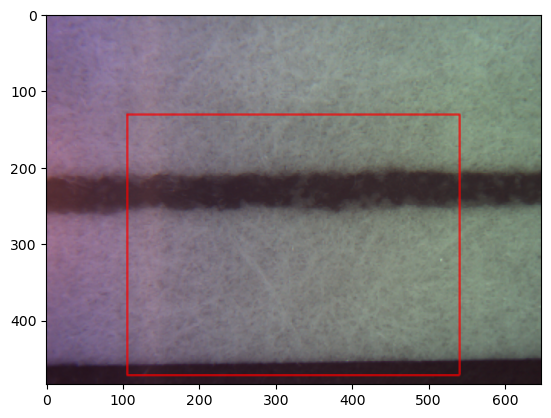

In [29]:

imgarr = np.array(octstudy.octdatalist[10].image)[:,:,0:3];
plt.imshow(imgarr[:,:,:])
print(imgarr.shape)


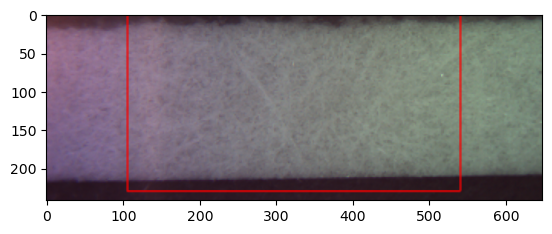

In [30]:

#x_slice = slice(imgarr.shape[0]//2)
slice_x = slice( imgarr.shape[0]//2+0, imgarr.shape[0]//2+imgarr.shape[0]//2);
plt.imshow(imgarr[slice_x,:,:])


 SliceX  : slice(106.494898275, 541.505101725, None)
 SliceY  : slice(130.66261596500001, 471.337384035, None)
SliceXint: slice(106, 541, None)
SliceYint: slice(130, 471, None)


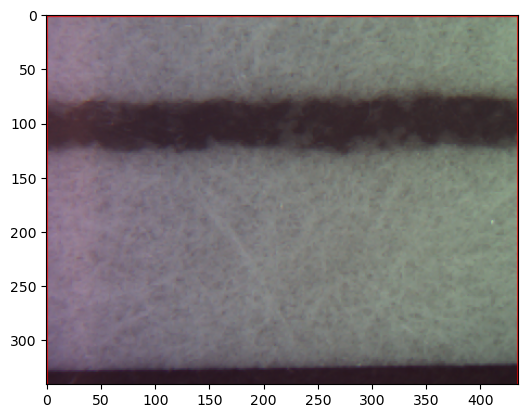

In [31]:
px_origin_x = imgarr.shape[1]//2-int(camera_scan_center_px_X);
px_origin_y = imgarr.shape[0]//2-int(camera_scan_center_px_Y);

camera_x_slice = slice(px_origin_x-(camera_scan_px_X/2) , px_origin_x+(camera_scan_px_X/2))
camera_y_slice = slice(px_origin_y-(camera_scan_px_Y/2) , px_origin_y+(camera_scan_px_Y/2))
print(' SliceX  :',camera_x_slice)
print(' SliceY  :',camera_y_slice)

camera_x_sliceint = slice(int(camera_x_slice.start),int(camera_x_slice.stop));
camera_y_sliceint = slice(int(camera_y_slice.start),int(camera_y_slice.stop));
print('SliceXint:', camera_x_sliceint )
print('SliceYint:', camera_y_sliceint )

plt.imshow(imgarr[ camera_y_sliceint , camera_x_sliceint , : ])

In [ ]:
if(octstudy.num_oct_files>=1):
    octstudy.folder_study_processed.mkdir(exist_ok=True);
    tmparrays = [];
    for count,octdata in enumerate(sorted(octstudy.octdatalist, key= lambda x: int(x.cfg_oct_xml.Ocity.Acquisition.Timestamp.etElem.text))):
        imgarr = np.array(octdata.image)[:,:,0:3];
        # slice using pre-determined areas corresponding to the oct scan
        tmparrays.append(imgarr[ camera_y_sliceint , camera_x_sliceint , : ]);


In [ ]:
# write image montage to .png in processed folder
img_camera_montage = Image.fromarray(np.concatenate(tmparrays,axis=1))
img_camera_montage.save((octstudy.folder_study_processed/('{:s}_montaged.png'.format(octstudy.name))))

In [ ]:
octstudy

# Test Line Extraction

In [ ]:
#pvvol = octstudy.octdatalist[10].pvvol;
pvvol = mergedvol;
pl = pv.Plotter(notebook=False);


#plt.add_volume(pvvol,opacity=0.1);
#pl.add_volume_clip_plane(pvvol,normal='x',assign_to_axis='x',cmap='grey',clim=[40,55]);
#pl.add_mesh_slice(pvvol,normal='x',assign_to_axis='x',cmap='grey',clim=[40,55]);
#pl.add_mesh_slice(pvvol,normal='y',assign_to_axis='y',cmap='grey',clim=[40,55]);
#pl.add_mesh_slice(pvvol,normal='y',cmap='grey',clim=[40,55]);
pl.add_mesh_slice(pvvol,normal='z',assign_to_axis='z',cmap='grey',clim=[40,55]);
#pl.add_mesh_slice(pvvol,normal='z',cmap='grey',clim=[40,55]);
#pl.add_mesh_slice_orthogonal(pvvol,cmap='grey',clim=[40,55]);

#pl.add_volume(pvvol,opacity=0.2);
# def callback(normal, origin):
#     slc = pvvol.slice(normal=normal, origin=origin)
#     origin = list(origin)
#     origin[2] = slc.bounds[5]
#     peak_plane = pv.Plane(
#         center=origin,
#         direction=[0, 0, 1],
#         i_size=20,
#         j_size=20,
#     )
#     _ = pl.add_mesh(
#         peak_plane, name="Peak", color='red', opacity=0.4
#     )
# _ = pl.add_plane_widget(callback, normal_rotation=False)

#pl.add_axes();

# def move_center(pointa, pointb):
#     center = (np.array(pointa) + np.array(pointb)) / 2
#     normal = np.array(pointa) - np.array(pointb)
#     single_slc = pvvol.slice(normal=normal, origin=center)

#     _ = pl.add_mesh(single_slc, name="slc")

# _ = pl.add_line_widget(callback=move_center, use_vertices=True)
pl.add_box_axes();
pl.show_bounds();

pl.show();

: 

: 

In [ ]:
p.plane_sliced_meshes[0].plot(notebook=False)

In [ ]:
from SimpleITK.utilities.vtk import vtk2sitk
simgmerged = vtk2sitk(mergedvol)

In [ ]:
plt = pv.Plotter(notebook=False);
plt.add_volume(mergedvol);
plt.show(jupyter_backend='none')


In [ ]:
import cv2